<h1 style="font-family:cursive; font-weight: bold; font-size: 40px;"> <center>Spam Email Deticion 📧</center> </h1>
<p><center style="color:#159364; font-family:cursive; font-size: 20px;">Natural Language Processing - NLP</center></p>

<div align="center">
  <img style = "border-radius: 15px;" src="https://camo.githubusercontent.com/a7d756449bad6072383da52721ceeff69f15c4df91d1c5a8e2e97d2d605b3e9b/68747470733a2f2f6d69726f2e6d656469756d2e636f6d2f6d61782f313430302f302a6d624642506350554a442d35337633682e706e67" width="900" height="600">
</div>g

## 📚 Import Liberaries

In [ ]:
import spacy 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings 
warnings.filterwarnings('ignore')

## 📝 Data Representaion

In [2]:
df = pd.read_csv(r'/kaggle/input/spam-emails/spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [4]:
df.isna().sum()

Category    0
Message     0
dtype: int64

In [5]:
df.duplicated().sum()

415

In [ ]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

## 📊 Exploratory Data Analysis - EDA

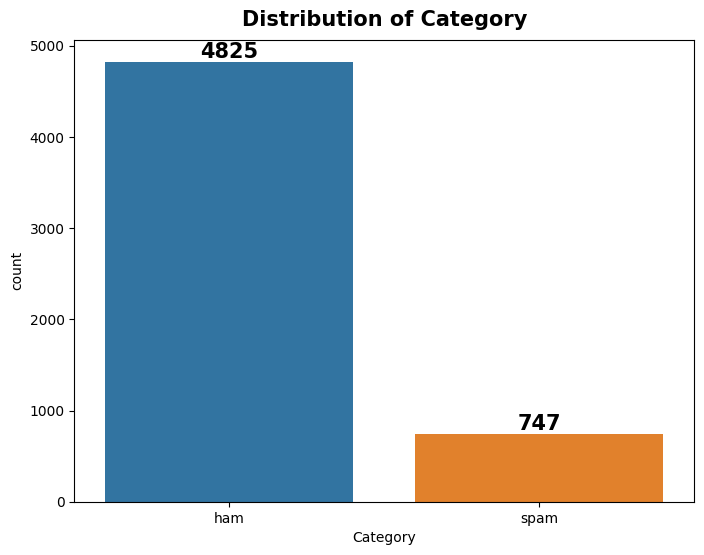

In [9]:
plt.figure(figsize = (8,6))
ax = sns.countplot(data = df, x = 'Category')
plt.title('Distribution of Category', fontweight = 'black', pad = 10, fontsize = 15)
for container in ax.containers:
    ax.bar_label(container, fontweight = 'black', size = 15)

## ⚙ Data Pre-processing

In [ ]:
nlp = spacy.load('en_core_web_md')

In [ ]:
text = df.iloc[0,1]

In [ ]:
doc = nlp(text)
doc

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

In [17]:
for token in doc:
    print(token)

Go
until
jurong
point
,
crazy
..
Available
only
in
bugis
n
great
world
la
e
buffet
...
Cine
there
got
amore
wat
...


In [18]:
for token in doc:
    print(token,'->', token.lemma_)

Go -> go
until -> until
jurong -> jurong
point -> point
, -> ,
crazy -> crazy
.. -> ..
Available -> available
only -> only
in -> in
bugis -> bugis
n -> n
great -> great
world -> world
la -> la
e -> e
buffet -> buffet
... -> ...
Cine -> Cine
there -> there
got -> get
amore -> amore
wat -> wat
... -> ...


In [19]:
for token in doc:
    if token.is_stop:
        print(f'{token} --> stop word')
    elif token.is_punct:
        print(f'{token} --> Punct')
    else:
        print(f'{token} --> Not Stop Word')

Go --> stop word
until --> stop word
jurong --> Not Stop Word
point --> Not Stop Word
, --> Punct
crazy --> Not Stop Word
.. --> Punct
Available --> Not Stop Word
only --> stop word
in --> stop word
bugis --> Not Stop Word
n --> Not Stop Word
great --> Not Stop Word
world --> Not Stop Word
la --> Not Stop Word
e --> Not Stop Word
buffet --> Not Stop Word
... --> Punct
Cine --> Not Stop Word
there --> stop word
got --> Not Stop Word
amore --> Not Stop Word
wat --> Not Stop Word
... --> Punct


In [20]:
def preprocessing(text):
    doc = nlp(text)
    clean_text = []

    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        clean_text.append(token.lemma_)


    return ' '.join(clean_text)

In [21]:
df['clean_text'] = df['Message'].apply(preprocessing)

In [22]:
df.head()

,Category,Message,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win FA Cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,U dun early hor U c
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think go usf live


In [23]:
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['Category'])

In [ ]:
df.head()

,Category,Message,clean_text,label
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win FA Cup final tkts 2...,1
3,ham,U dun say so early hor... U c already then say...,U dun early hor U c,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think go usf live,0


In [25]:
X = df['clean_text']
y = df['label']

In [26]:
vectorizer = TfidfVectorizer()

X_vectorizer = vectorizer.fit_transform(X)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorizer, y, test_size = 0.2, random_state = 42)

## 🚂 Train Model

### Logistic Regression

In [29]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [30]:
lr.score(X_train, y_train)

0.9681400044873233

In [31]:
y_pred = lr.predict(X_test)

In [32]:
print(accuracy_score(y_test,y_pred))

0.957847533632287


<Axes: >

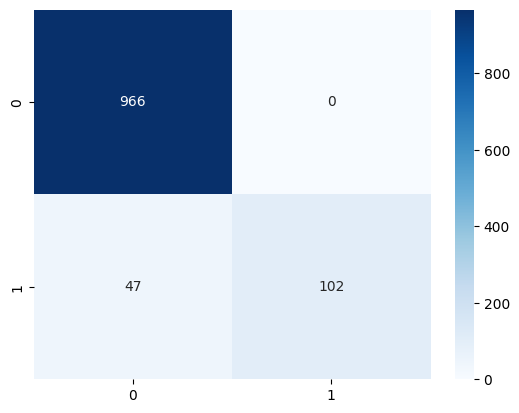

In [33]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm, annot = True, cmap = 'Blues',fmt = '1.0f')

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       966
           1       1.00      0.68      0.81       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



### Support Vector Machine - SVM

In [40]:
svm = SVC(kernel = 'linear', random_state = 42)
svm.fit(X_train,y_train)

SVC(kernel='linear', random_state=42)

In [41]:
svm_pred = svm.predict(X_test)

In [42]:
print(accuracy_score(y_test,svm_pred))

0.9820627802690582


<Axes: >

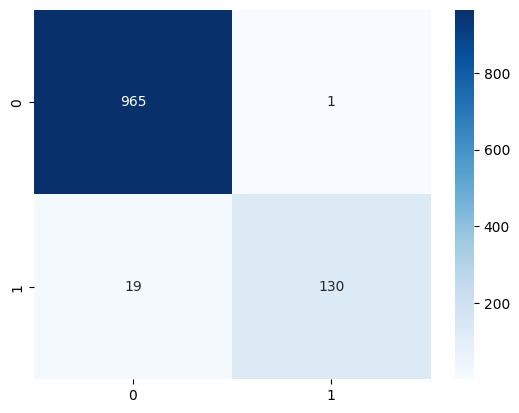

In [43]:
cm = confusion_matrix(y_test,svm_pred)

sns.heatmap(cm, annot = True, cmap = 'Blues', fmt = '1.0f')

In [44]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

